### Build a Basic Chatbot with LangGraph (GRAPH API)

#### Components of LangGraph

1. **Edges**

   * Connect one node to another
   * Decide the flow of execution

2. **Nodes**

   * Individual functions or tasks in the workflow
   * Perform operations like processing data or calling LLMs

3. **State**

   * Shared memory/data passed between nodes
   * Stores information during execution

---

#### LangGraph APIs

1. **Graph API**

   * Used to build workflows using nodes and edges visually/logically

2. **Functional API**

   * Used to create workflows using functions directly

---

#### Example Workflow

##### Flow:

`Transcript → Title Generator → Content Generator`

##### Explanation:

* **Transcript Node**
  Takes input transcript/text

* **Edge**
  Passes transcript to next node

* **Title Generator Node**
  Generates a title from transcript

* **Edge**
  Passes title + transcript forward

* **Content Generator Node**
  Generates final content/article

* **End**
  Workflow finishes after content generation


#### Reducers in LangGraph

Reducers define **how state updates are merged** when multiple nodes modify the same state field.

They help manage and combine data safely inside the graph.

---

#### Why Reducers are Needed

Without reducers:

* New values overwrite old values

With reducers:

* Values can be appended, merged, or combined intelligently

---

#### Common Reducer Example

##### `add_messages`

Used for chat/message history.

```python id="r2m8vx"
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]
```

##### What it does:

* Automatically appends new messages
* Preserves conversation history

---

#### Example Without Reducer

```python id="k7x1qp"
class State(TypedDict):
    messages: list
```

Problem:

* New messages replace old ones

---

#### Example With Reducer

```python id="m4v9tc"
class State(TypedDict):
    messages: Annotated[list, add_messages]
```

Result:

* Old + new messages are combined

---

#### Reducer Flow Example

Initial state:

```python id="f8z2ny"
{
    "messages": ["Hi"]
}
```

New update:

```python id="z3p6qw"
{
    "messages": ["How are you?"]
}
```

After reducer:

```python id="w5x8er"
{
    "messages": ["Hi", "How are you?"]
}
```

---

#### Custom Reducers

You can create your own reducer function.

```python id="n9k2lm"
def add_numbers(current, new):
    return current + new
```

Use it in state:

```python id="c4q7xt"
class State(TypedDict):
    numbers: Annotated[list[int], add_numbers]
```

---

#### Key Points

* Reducers control state merging
* Useful when multiple nodes update same key
* `add_messages` is the most commonly used reducer
* Custom reducers can be created for special logic


In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [10]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them).

    messages:Annotated[list, add_messages]       # hey append the messages to the list rather than replacing them

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [17]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "qwen/qwen3-32b",
    model_provider="groq"
)

llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D926B8C590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D926B8FC50>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [18]:
# Node Functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}    # state of messages is my input message, llm will priovide the response for this and append it in our messages variable

In [19]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot" , chatbot)     # ("node_name" , node_implementation)

## Adding edges
graph_builder.add_edge(START , "llmchatbot")       # we are going from start -> node (i.e. llmchatbot here , specify the node name here)
graph_builder.add_edge("llmchatbot" , END)

## Compile the graph
graph = graph_builder.compile()

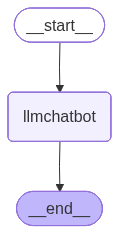

In [20]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [22]:
response = graph.invoke({"messages": "Hi"})

In [24]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s pretty casual. I should respond in a friendly and welcoming way. Let me make sure to keep it open-ended so they feel comfortable to ask anything. Maybe something like, "Hello! How can I assist you today?" That should work. I need to keep the tone positive and approachable. Alright, ready to send that.\n</think>\n\nHello! How can I assist you today? 😊'

In [ ]:
## Streaming
for event in graph.stream({"messages": "Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user is asking how I am doing. I should be friendly and offer help.

First, I need to respond in a cheerful way. Greeting them back and letting them know I'm here to help.

I should keep the tone positive and open-ended so they feel comfortable asking anything. Maybe add an emoji to keep it friendly.

Make sure the response is concise but not too short. Just enough to show I'm attentive and ready to assist.
</think>

Hi there! I'm doing great, thanks for asking! 😊 How can I assist you today? I'm here to help with any questions or tasks you might have. What's on your mind?
